In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Were created in create_adj_embs.
adj_embs = torch.load('data/graphs/weighted/adj_embs.pt')

In [3]:
similarities_np = cosine_similarity(adj_embs.detach().numpy())
assert np.allclose(similarities_np, similarities_np.T, atol=1e-6)

In [5]:
# similarities = torch.tensor(similarities_np)
# assert torch.allclose(similarities, similarities.T, atol=1e-6)

similarities = similarities_np

In [6]:
import pickle

with open('data/graphs/weighted/adj_feats__cosine__similarities.pickle', 'wb') as f:
    pickle.dump(similarities, f)

(array([1.3944e+04, 9.1000e+01, 8.6000e+01, 6.5000e+01, 2.6000e+01,
        2.9000e+01, 4.9000e+01, 2.3000e+01, 1.0000e+01, 2.0000e+01]),
 array([0.        , 0.08044324, 0.16088649, 0.24132973, 0.32177298,
        0.40221622, 0.48265947, 0.56310271, 0.64354596, 0.7239892 ,
        0.80443244]),
 <BarContainer object of 10 artists>)

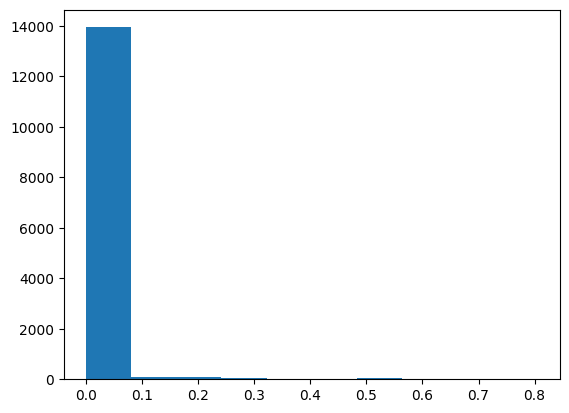

In [7]:
import matplotlib.pyplot as plt

plt.hist(similarities[0][1:])

In [8]:
similarities[0][1:].min(), similarities[0][1:].max()

(0.0, 0.8044324442267727)

In [9]:
for i in range(len(similarities)):
    similarities[i][i] = float('nan')

Отличие двух имплементаций ниже в возвращаемом типе. В первом случае возвращается список отсортированных списков, во втором - список множеств. Сложность первого - O(n*log(n)), второго - O(n).

In [10]:
from typing import List, Iterable, Optional


def create_sorted_bins_for_user(values: Iterable[int], 
                                n_bins: int, 
                                exclude_id: Optional[int] = None) -> List[List[int]]:
    indexed_values = list((idx, val) for idx, val in enumerate(values) if idx != exclude_id)
    indexed_values.sort(key=lambda x: x[1])

    min_val, max_val = indexed_values[0][1], indexed_values[-1][1]
    bin_size = (max_val - min_val) / n_bins
    
    bins = [[] for _ in range(n_bins)]
    
    # eps был добавлен, чтобы не делить на 0, если все элементы имеют одно значение.
    # в цикле есть обработка ситуации, когда bin_idx = n_bins (заметим, что при данной имплементации
    # правая граница бина в него не входит и поэтому отдельная обработка). 
    # Эта обработка также становится ненужной с eps
    eps = 1e-6
    for idx, val in indexed_values:
        bin_idx = int((val - min_val) // (bin_size + eps))
        if bin_idx == n_bins:
            bin_idx -= 1
        bins[bin_idx].append(idx)

    return bins

In [11]:
from typing import List, Iterable, Optional, Set

def create_bins_for_user(values: Iterable[int], 
                         n_bins: int, 
                         exclude_id: Optional[int] = None) -> List[Set[int]]:
    indexed_values = list((idx, val) for idx, val in enumerate(values) if idx != exclude_id)

    # `indexed_values` is used instead of `values` to exclude `exclude_id` from the calculation
    min_val, max_val = min(indexed_values, key=lambda x: x[1])[1], max(indexed_values, key=lambda x: x[1])[1]
    bin_size = (max_val - min_val) / n_bins
    
    bins = [set() for _ in range(n_bins)]
    
    # eps был добавлен, чтобы не делить на 0, если все элементы имеют одно значение.
    # в цикле есть обработка ситуации, когда bin_idx = n_bins (заметим, что при данной имплементации
    # правая граница бина в него не входит и поэтому отдельная обработка). 
    # Эта обработка также становится ненужной с eps
    eps = 1e-6
    for idx, val in indexed_values:
        bin_idx = int((val - min_val) // (bin_size + eps))
        if bin_idx == n_bins:
            bin_idx -= 1
        bins[bin_idx].add(idx)

    bins = np.array([frozenset(bin_) for bin_ in bins], dtype=object)
        
    return bins

In [13]:
def test_create_bins_for_user(create_bins_for_user_fn, bins_are_sets=False):
    # Test 1: Basic test with 3 bins
    values = [5, 3, 8, 6, 2, 7, 1, 9]
    n_bins = 3
    bins = create_bins_for_user_fn(values, n_bins)
    expected = [[6, 4, 1], [0, 3], [5, 2, 7]]
    if bins_are_sets:
        expected = [set(bin) for bin in expected]
    assert bins == expected, f"Expected {expected}, but got {bins}"

    # Test 2: Test with 2 bins
    values = [10, 20, 30, 40, 50]
    n_bins = 2
    bins = create_bins_for_user_fn(values, n_bins)
    expected = [[0, 1, 2], [3, 4]]
    if bins_are_sets:
        expected = [set(bin) for bin in expected]
    assert bins == expected, f"Expected {expected}, but got {bins}"

    # Test 3: Test with 1 bin (all values should be in the same bin)
    values = [10, 20, 30, 40, 50]
    n_bins = 1
    bins = create_bins_for_user_fn(values, n_bins)
    expected = [[0, 1, 2, 3, 4]]
    if bins_are_sets:
        expected = [set(bin) for bin in expected]
    assert bins == expected, f"Expected {expected}, but got {bins}"

    # Test 4: Test with all values being the same
    values = [100, 100, 100, 100, 100]
    n_bins = 1
    bins = create_bins_for_user_fn(values, n_bins)
    expected = [[0, 1, 2, 3, 4]]
    if bins_are_sets:
        expected = [set(bin) for bin in expected]
    assert bins == expected, f"Expected {expected}, but got {bins}"

    # Test 5: Test with excluding a value
    values = [10, 20, 30, 40, 50]
    n_bins = 2
    exclude_id = 2
    bins = create_bins_for_user_fn(values, n_bins, exclude_id)
    expected = [[0, 1], [3, 4]]
    if bins_are_sets:
        expected = [set(bin) for bin in expected]
    assert bins == expected, f"Expected {expected}, but got {bins}"

    # Test 6: Test with expected empty bins
    values = [1, 2, 2, 2, 100, 101, 101]
    n_bins = 5
    bins = create_bins_for_user_fn(values, n_bins)
    if bins_are_sets:
        expected = [set(bin) for bin in expected]
    print(bins)


    # # Test 6: Test with more bins than values (some bins will be empty)
    # values = [1, 2, 3]
    # n_bins = 5
    # bins = create_bins_for_user_fn(values, n_bins)
    # expected = [[0], [1], [2], [], []]
    # assert bins == expected, f"Expected {expected}, but got {bins}"

    # # Test 7: Test with empty values
    # values = []
    # n_bins = 3
    # bins = create_bins_for_user_fn(values, n_bins)
    # expected = [[], [], []]
    # assert bins == expected, f"Expected {expected}, but got {bins}"

    # # Test 8: Test with a single value
    # values = [42]
    # n_bins = 3
    # bins = create_bins_for_user_fn(values, n_bins)
    # expected = [[0], [], []]
    # assert bins == expected, f"Expected {expected}, but got {bins}"

    print("All tests passed!")

# Run the tests
test_create_bins_for_user(create_sorted_bins_for_user)
test_create_bins_for_user(create_bins_for_user, bins_are_sets=True)

[[0, 1, 2, 3], [], [], [], [4, 5, 6]]
All tests passed!


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [15]:
from tqdm import tqdm

n_bins = 10
n_users = len(similarities)

user_bins = np.empty(n_users, dtype=object)

for anchor_user_id, anchor_user_similarities in tqdm(enumerate(similarities), total=len(similarities)):
    user_bins[anchor_user_id] = create_bins_for_user(anchor_user_similarities, n_bins, exclude_id=anchor_user_id)
    if anchor_user_id > 6000:
        break

 42%|████▏     | 6001/14344 [02:15<03:07, 44.40it/s]


**List[np.array[frozenset]]

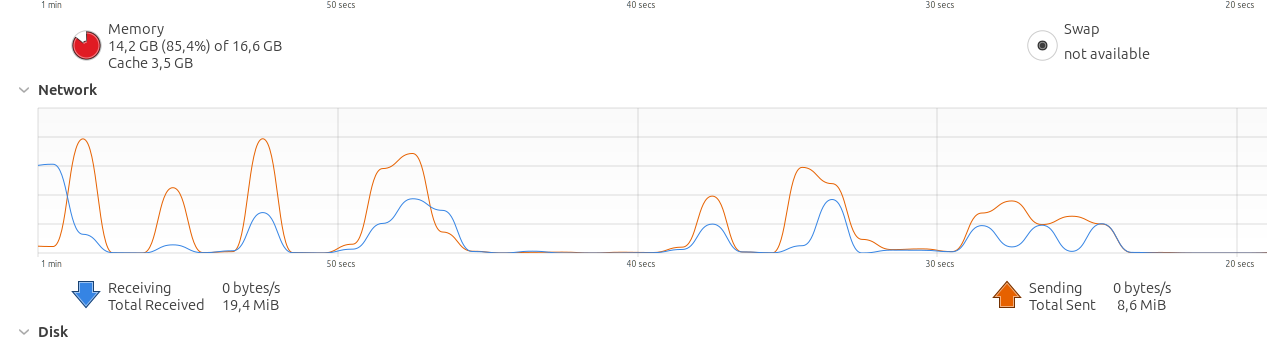

In [ ]:
import sys

def sizeof(obj):
    size = sys.getsizeof(obj)
    if isinstance(obj, dict): return size + sum(map(sizeof, obj.keys())) + sum(map(sizeof, obj.values()))
    if isinstance(obj, (list, tuple, set, frozenset)): return size + sum(map(sizeof, obj))
    return size

In [15]:
user_bins[0][0].nbytes

AttributeError: 'frozenset' object has no attribute 'nbytes'

In [ ]:
sizeof(user_bins)

**If there was no overhead**

6002 rows x 14353 ints per row x 4 bytes per bit = 344256000 bytes ~ 340Mb

**List[List[Set[int]]]:**


6002 rows


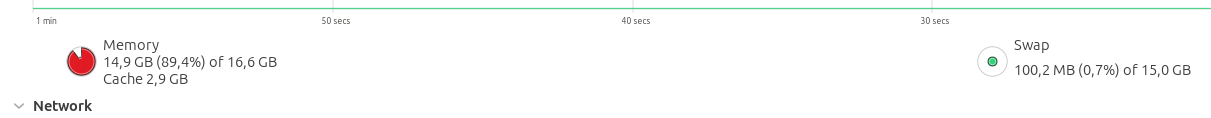


`sizeof(user_bins)` = 6530665628 ~ 6.5Gb

In [23]:
for anchor_user_id, anchor_user_bins in enumerate(user_bins):
    new_anchor_user_bins = [frozenset(bin_) for bin_ in anchor_user_bins]
    user_bins[anchor_user_id] = new_anchor_user_bins


In [24]:
sizeof(user_bins)

6237286556

**After conversion to frozenset**

**List[List[FrozenSet[int]]]:**

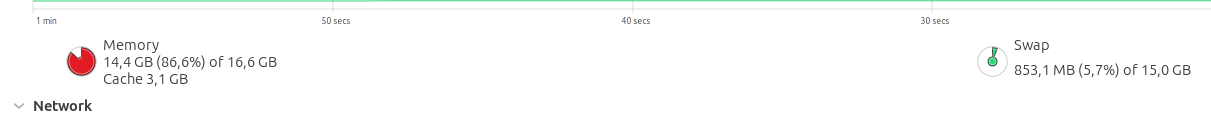

`sizeof(user_bins)` = 6237286556 ~ 6.2Gb

In [25]:
bins_array = np.array(user_bins, dtype=object)

In [26]:
sizeof(bins_array)

480288

In [ ]:
sizeof(bins_array)

480288

In [1]:
import pickle

with open('data/graphs/weighted/bins__adj_embs-cosine_similarity-no_postprocessing.pickle', 'rb') as f:
    user_bins = pickle.load(f)

for anchor_user_id, anchor_user_bins in enumerate(user_bins):
    new_anchor_user_bins = [set(bin_) for bin_ in anchor_user_bins]
    user_bins[anchor_user_id] = new_anchor_user_bins

In [29]:
import os
import pickle

BIN_OUTPUT_DIR_PATH = 'data/graphs/weighted/'

with open(os.path.join(BIN_OUTPUT_DIR_PATH, 'bins__adj_embs-unordered-cosine_similarity-no_postprocessing.pickle'), 'wb') as f:
    pickle.dump(user_bins, f)

In [30]:
n_empty_bins = 0
for anchor_user_bins in user_bins:
    for bin in anchor_user_bins:
        if not bin:
            n_empty_bins += 1
            

In [32]:
n_empty_bins / len(user_bins) / len(user_bins[0])

0.014974902398215282

In [44]:
import numpy as np

def compute_bin_n_elements_statistics(bins_list):
    # Determine the number of bin positions (based on the first sublist)
    num_bins = len(bins_list[0])
    
    statistics = []
    for i in tqdm(range(num_bins)):
        bin_group = [bins[i] for bins in bins_list if i < len(bins)]
        n_elements_in_each_i_group = [len(bin) for bin in bin_group]
        n_elements_in_each_i_group = np.array(n_elements_in_each_i_group)

        mean = np.mean(n_elements_in_each_i_group)
        std_dev = np.std(n_elements_in_each_i_group)
        min_val = np.min(n_elements_in_each_i_group)
        max_val = np.max(n_elements_in_each_i_group)
        
        statistics.append({
            'bin_index': i,
            'n_elements-mean': mean,
            'n_elements-std_dev': std_dev,
            'n_elements-min': min_val,
            'n_elements-max': max_val
        })
    
    return statistics


def compute_bin_statistics(bins_list):
    num_bins = len(bins_list[0])

    statistics = []
    for i in range(num_bins):
        bin_group = [bins[i] for bins in bins_list if i < len(bins)]
        flattened_bin_group = [item for sublist in bin_group for item in sublist]
        flattened_bin_group = np.array(flattened_bin_group)
        
        mean = np.mean(flattened_bin_group)
        std_dev = np.std(flattened_bin_group)
        min_val = np.min(flattened_bin_group)
        max_val = np.max(flattened_bin_group)
        
        statistics.append({
            'bin_index': i,
            'mean': mean,
            'std_dev': std_dev,
            'min': min_val,
            'max': max_val
        })
    
    return statistics



In [45]:
compute_bin_n_elements_statistics(user_bins)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 115.62it/s]


[{'bin_index': 0,
  'n_elements-mean': 11566.745050195204,
  'n_elements-std_dev': 2126.7621353432205,
  'n_elements-min': 4751,
  'n_elements-max': 14343},
 {'bin_index': 1,
  'n_elements-mean': 1445.6347601784719,
  'n_elements-std_dev': 1065.5902031937694,
  'n_elements-min': 0,
  'n_elements-max': 4838},
 {'bin_index': 2,
  'n_elements-mean': 555.2979643056331,
  'n_elements-std_dev': 518.4681263367003,
  'n_elements-min': 0,
  'n_elements-max': 2987},
 {'bin_index': 3,
  'n_elements-mean': 279.67645008365866,
  'n_elements-std_dev': 295.99708293169726,
  'n_elements-min': 0,
  'n_elements-max': 2139},
 {'bin_index': 4,
  'n_elements-mean': 161.40679029559396,
  'n_elements-std_dev': 187.23299549632125,
  'n_elements-min': 0,
  'n_elements-max': 1609},
 {'bin_index': 5,
  'n_elements-mean': 104.80305354155047,
  'n_elements-std_dev': 133.03754324683007,
  'n_elements-min': 0,
  'n_elements-max': 1091},
 {'bin_index': 6,
  'n_elements-mean': 73.38078639152259,
  'n_elements-std_dev'

In [47]:
def remove_empty_bins_(bins_list: List[List[List[int]]]) -> None:
    for anchor_user_id, anchor_user_bins in enumerate(bins_list):
        new_anchor_user_bins = []
        for bin in anchor_user_bins:
            if bin:
                new_anchor_user_bins.append(bin)
        bins_list[anchor_user_id] = new_anchor_user_bins



In [48]:
remove_empty_bins_(user_bins)

In [50]:
avg_n_bins = np.mean([len(bins) for bins in user_bins])
avg_n_bins

9.850250976017847

In [51]:
with open(os.path.join(BIN_OUTPUT_DIR_PATH, 'bins__adj_embs-cosine_similarity-deleted_empty_bins.pickle'), 'wb') as f:
    pickle.dump(user_bins, f)

In [57]:
# Check that for each user all users except the user themselves are in the bins
n_users = len(user_bins)

for anchor_user_id, anchor_user_bins in tqdm(enumerate(user_bins), total=n_users):
    bins_set = set()
    for bin in anchor_user_bins:
        bins_set.update(bin)
    assert bins_set == set(range(n_users)) - {anchor_user_id}

  0%|          | 0/14344 [00:00<?, ?it/s]

 61%|██████    | 8736/14344 [00:10<00:06, 845.47it/s]

In [14]:
similarities[0,1]

tensor(0.0060, dtype=torch.float64)

# Extra: 

In [ ]:
import dgl


GRAPH_FILE_PATH = 'data/graphs/weighted/train_graph.bin'

(g_list,), _ = dgl.load_graphs(GRAPH_FILE_PATH, [0])

g_list.edata['weight']